In [2]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

In [3]:
random_root = Path('/home/ddon0001/PhD/experiments/scaled/pre-thesis/sparse_sampling/edge_precision_random')
traj_root = Path('/home/ddon0001/PhD/experiments/scaled/pre-thesis/sparse_sampling/edge_precision_trajectory')

def load_method(root, method_name):
    dfs = []
    for f in sorted(root.glob('*.csv')):
        df = pd.read_csv(f)
        df['method'] = method_name
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

random_df = load_method(random_root, 'random')
traj_df = load_method(traj_root, 'trajectory')
df = pd.concat([random_df, traj_df], ignore_index=True)
print(df['ds_name'].nunique(), 'datasets,', df['method'].unique(), 'methods')
df.head()

32 datasets, ['random' 'trajectory'] methods


,ds_name,run_id,sample_id,edge_src,edge_tgt,is_tp,prec_estimate,std_error,method
0,BF-C2DL-HSC_01,0,0,8303,8315,True,1.0,0.0,random
1,BF-C2DL-HSC_01,0,1,4778,4786,True,1.0,0.0,random
2,BF-C2DL-HSC_01,0,2,1375,1379,True,1.0,0.0,random
3,BF-C2DL-HSC_01,0,3,5617,5625,True,1.0,0.0,random
4,BF-C2DL-HSC_01,0,4,1572,1576,True,1.0,0.0,random


In [4]:
# load n edges and true precision for each dataset
true_prec_root = '/home/ddon0001/PhD/experiments/scaled/pre-thesis/scaled_no_merge_cap'
records = []
for ds_name in random_df.ds_name.unique():
    metrics_path = f'{true_prec_root}/{ds_name}/matched_solution.zarr/traccuracy-results.json'
    with open(metrics_path, 'r') as f:
        metrics = json.load(f)['traccuracy'][0]['results']
    n_edges = metrics['Total Pred Edges']
    true_prec = metrics['Edge Precision']
    records.append({
        'ds_name': ds_name,
        'n_edges': n_edges,
        'true_precision': true_prec
    })
ds_info = pd.DataFrame(records)

In [5]:
df = df.merge(ds_info[['ds_name', 'n_edges']], on='ds_name')
df['frac_sampled'] = (df['sample_id'] + 1) / df['n_edges']

# aggregate across 30 runs: mean estimate, empirical SD across runs, mean theoretical SE
stats = (
    df.groupby(['ds_name', 'method', 'sample_id'])
    .agg(
        frac_sampled=('frac_sampled', 'first'),
        # over the 30 different runs
        mean_prec=('prec_estimate', 'mean'),
        # worked out over our 30 runs
        empirical_se=('prec_estimate', 'std'),
        # worked out using the finite population correction as we sample 
        # if this is close to the empirical SE, it means we can use this
        # estimate as we annotate
        mean_theoretical_se=('std_error', 'mean'),
    )
    .reset_index()
)

stats = stats.merge(ds_info[['ds_name', 'true_precision']], on='ds_name')
stats = stats[stats['true_precision'] < 1.0]
ds_info = ds_info[ds_info['true_precision'] < 1.0]
stats.head()

,ds_name,method,sample_id,frac_sampled,mean_prec,empirical_se,mean_theoretical_se,true_precision
0,BF-C2DL-HSC_01,random,0,0.000115,1.0,0.0,0.0,0.998962
1,BF-C2DL-HSC_01,random,1,0.000231,1.0,0.0,0.0,0.998962
2,BF-C2DL-HSC_01,random,2,0.000346,1.0,0.0,0.0,0.998962
3,BF-C2DL-HSC_01,random,3,0.000461,1.0,0.0,0.0,0.998962
4,BF-C2DL-HSC_01,random,4,0.000577,1.0,0.0,0.0,0.998962


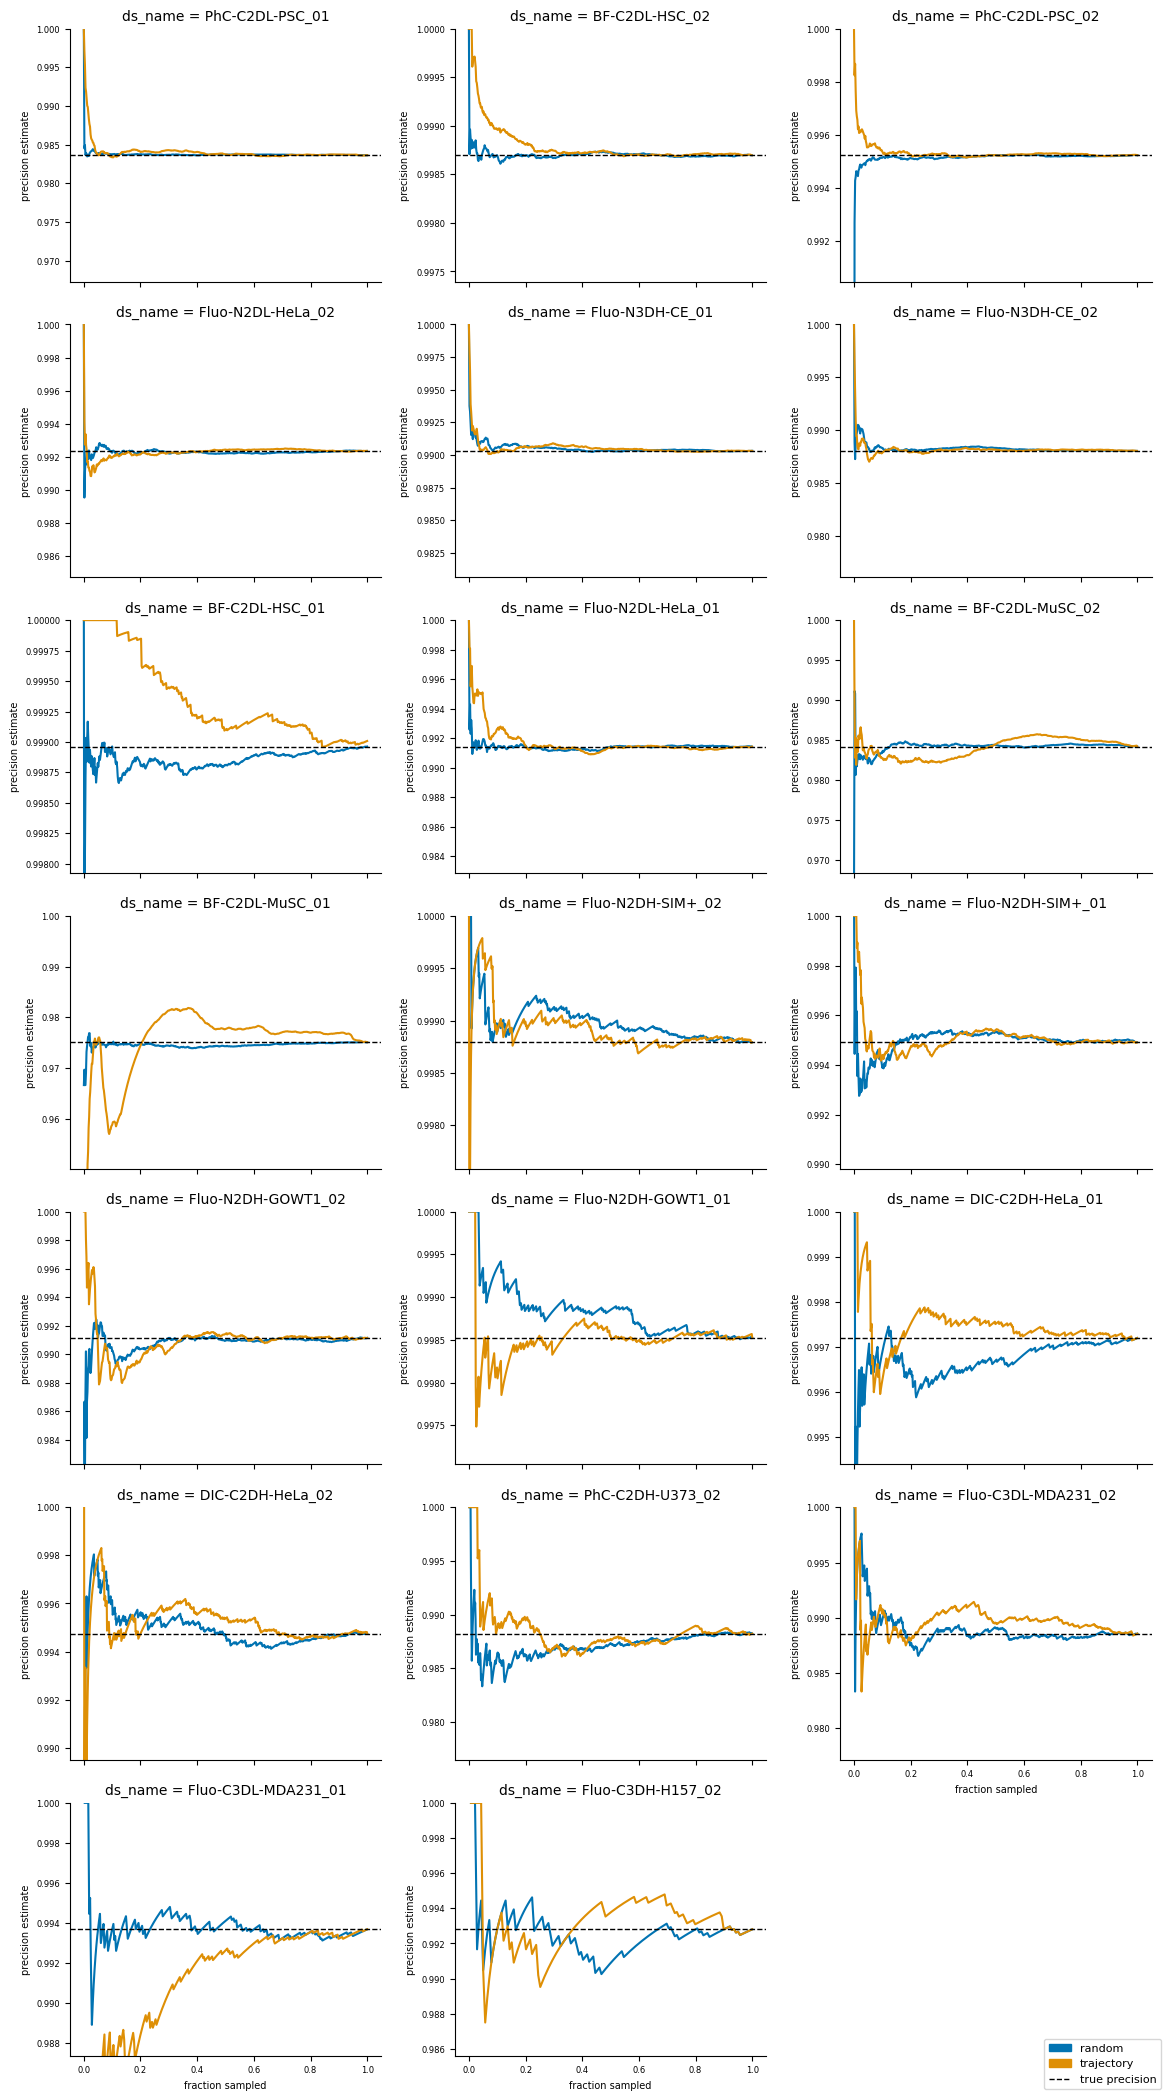

In [6]:
import seaborn as sns

z = 1.96
colors = {'random': sns.color_palette("colorblind")[0], 'trajectory': sns.color_palette("colorblind")[1]}
col_order = ds_info.sort_values(by='n_edges', ascending=False)['ds_name'].tolist()

def plot_convergence(data, color, **kwargs):
    stride = max(1, len(data) // 500)
    data = data.iloc[::stride]
    x = data['frac_sampled']
    y = data['mean_prec']
    # for bound in (-1, 1):
    #     plt.plot(x, y + bound * z * data['mean_theoretical_se'], color=color, linewidth=0.8, linestyle='--')
    #     plt.plot(x, y + bound * z * data['empirical_se'], color=color, linewidth=0.8, linestyle=':')
    plt.plot(x, y, color=color, linewidth=1.5)

g = sns.FacetGrid(
    stats,
    col='ds_name',
    col_order=col_order,
    col_wrap=3,
    hue='method',
    palette=colors,
    height=3,
    aspect=1.3,
    sharey=False
)
g.map_dataframe(plot_convergence)

for ax, ds_name in zip(g.axes.flatten(), col_order):
    true_p = ds_info.loc[ds_info['ds_name'] == ds_name, 'true_precision'].values[0]
    ax.axhline(true_p, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('fraction sampled', fontsize=7)
    ax.set_ylabel('precision estimate', fontsize=7)
    # print(ds_name, true_p, true_p - (1 - true_p), 1)
    ax.set_ylim(true_p - (1 - true_p), 1)
    ax.tick_params(labelsize=6)

legend_handles = [
    mpatches.Patch(color=colors['random'], label='random'),
    mpatches.Patch(color=colors['trajectory'], label='trajectory'),
    # plt.Line2D([0], [0], color='grey', linewidth=0.8, linestyle='--', label='theoretical ±1.96 SE'),
    # plt.Line2D([0], [0], color='grey', linewidth=0.8, linestyle=':', label='empirical ±1.96 SE'),
    plt.Line2D([0], [0], color='black', linestyle='--', linewidth=1, label='true precision'),
]
g.figure.legend(handles=legend_handles, loc='lower right', fontsize=8, bbox_to_anchor=(1.0, 0.0))
# plt.tight_layout()

# for ax, ds_name in zip(g.axes.flatten(), col_order):
#     true_p = ds_info.loc[ds_info['ds_name'] == ds_name, 'true_precision'].iloc[0]
#     ax.set_ylim(true_p - 0.02, true_p + 0.02)

plt.show()

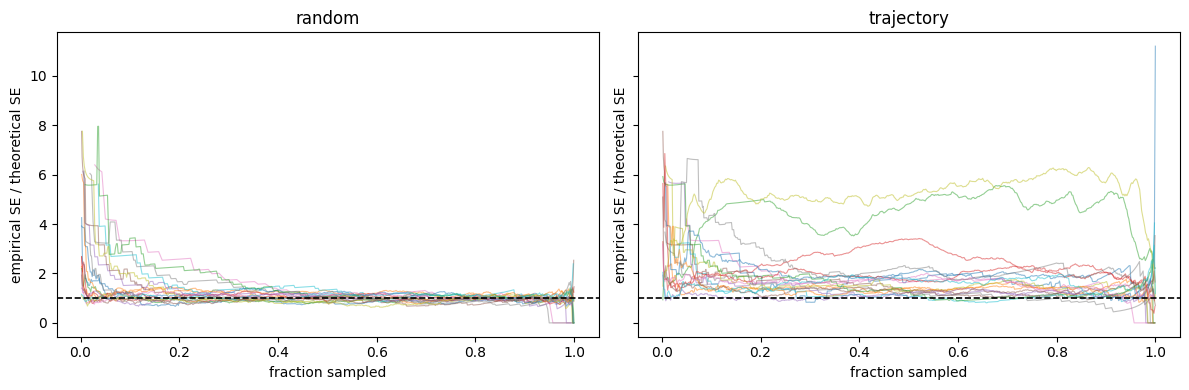

In [7]:
ratio_stats = stats.copy()
# avoid division by zero at sample_id=0 where both SEs are 0
ratio_stats['se_ratio'] = ratio_stats['empirical_se'] / ratio_stats['mean_theoretical_se'].replace(0, float('nan'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, method in zip(axes, ['random', 'trajectory']):
    sub = ratio_stats[ratio_stats['method'] == method]
    for ds_name, group in sub.groupby('ds_name'):
        stride = max(1, len(group) // 500)
        group = group.iloc[::stride]
        ax.plot(group['frac_sampled'], group['se_ratio'], linewidth=0.8, alpha=0.5)
    ax.axhline(1.0, color='black', linewidth=1.2, linestyle='--')
    ax.set_title(method)
    ax.set_xlabel('fraction sampled')
    ax.set_ylabel('empirical SE / theoretical SE')

plt.tight_layout()
plt.show()

In [31]:
THRESHOLD = 0.005

def convergence_fraction(group):
    """Smallest frac_sampled where |error| drops and stays below threshold.
    Returns conv_frac and the actual error at that point."""
    error = (group['prec_estimate'] - group['true_precision']).abs()
    group['prec_error'] = error
    above = (error >= THRESHOLD) | (group['prec_estimate'] == 1)
    if not above.any():
        return pd.Series({'conv_frac': group['frac_sampled'].iloc[0], 'error_at_conv': error.iloc[0]})
    if above.all():
        return pd.Series({'conv_frac': float('nan'), 'error_at_conv': float('nan')})
    last_above_pos = len(above) - 1 - above.values[::-1].argmax()
    conv_idx = last_above_pos + 1
    return pd.Series({'conv_frac': group['frac_sampled'].iloc[conv_idx], 'error_at_conv': error.iloc[conv_idx]})

# work on per-run data, merging in true_precision and frac_sampled
conv_df = df[df['ds_name'].isin(stats['ds_name'].unique())].copy()
conv_df = conv_df.merge(ds_info[['ds_name', 'true_precision']], on='ds_name')

conv_per_run = (
    conv_df.groupby(['ds_name', 'method', 'run_id'])
    .apply(convergence_fraction, include_groups=False)
    .reset_index()
)

# summarise across runs
conv = (
    conv_per_run.groupby(['ds_name', 'method'])
    .agg(
        conv_frac_median=('conv_frac', 'median'),
        conv_frac_p95=('conv_frac', lambda x: x.quantile(0.95)),
        error_at_conv_median=('error_at_conv', 'median'),
    )
    .reset_index()
)
conv = conv.merge(ds_info[['ds_name', 'n_edges', 'true_precision']], on='ds_name')
conv['conv_n_edges_median'] = (conv['conv_frac_median'] * conv['n_edges']).round().astype(int)
conv.sort_values('conv_frac_median')

,ds_name,method,conv_frac_median,conv_frac_p95,error_at_conv_median,n_edges,true_precision,conv_n_edges_median
39,PhC-C2DL-PSC_02,trajectory,0.005165,0.017927,0.002398,56628,0.995232,292
38,PhC-C2DL-PSC_02,random,0.005439,0.015588,0.004941,56628,0.995232,308
36,PhC-C2DL-PSC_01,random,0.007034,0.048667,0.004717,70941,0.983634,499
2,BF-C2DL-HSC_02,random,0.008101,0.032677,0.000833,64499,0.998698,522
28,Fluo-N2DL-HeLa_02,random,0.010720,0.047500,0.004863,25140,0.992363,270
29,Fluo-N2DL-HeLa_02,trajectory,0.016687,0.074773,0.004968,25140,0.992363,419
30,Fluo-N3DH-CE_01,random,0.020090,0.048288,0.003903,23743,0.990313,477
32,Fluo-N3DH-CE_02,random,0.022422,0.106183,0.004668,22166,0.988045,497
3,BF-C2DL-HSC_02,trajectory,0.027248,0.051888,0.000732,64499,0.998698,1758
31,Fluo-N3DH-CE_01,trajectory,0.033147,0.100676,0.004499,23743,0.990313,787


In [32]:
conv

,ds_name,method,conv_frac_median,conv_frac_p95,error_at_conv_median,n_edges,true_precision,conv_n_edges_median
0,BF-C2DL-HSC_01,random,0.069930,0.170212,0.000618,8673,0.998962,606
1,BF-C2DL-HSC_01,trajectory,0.203275,0.291249,0.000470,8673,0.998962,1763
2,BF-C2DL-HSC_02,random,0.008101,0.032677,0.000833,64499,0.998698,522
3,BF-C2DL-HSC_02,trajectory,0.027248,0.051888,0.000732,64499,0.998698,1758
4,BF-C2DL-MuSC_01,random,0.171033,0.383231,0.004953,5382,0.975102,920
5,BF-C2DL-MuSC_01,trajectory,0.823021,0.945866,0.004987,5382,0.975102,4429
6,BF-C2DL-MuSC_02,random,0.079284,0.225771,0.004946,7202,0.984171,571
7,BF-C2DL-MuSC_02,trajectory,0.496668,0.669085,0.004996,7202,0.984171,3577
8,DIC-C2DH-HeLa_01,random,0.239739,0.626119,0.002593,1072,0.997201,257
9,DIC-C2DH-HeLa_01,trajectory,0.271922,0.640718,0.001322,1072,0.997201,292


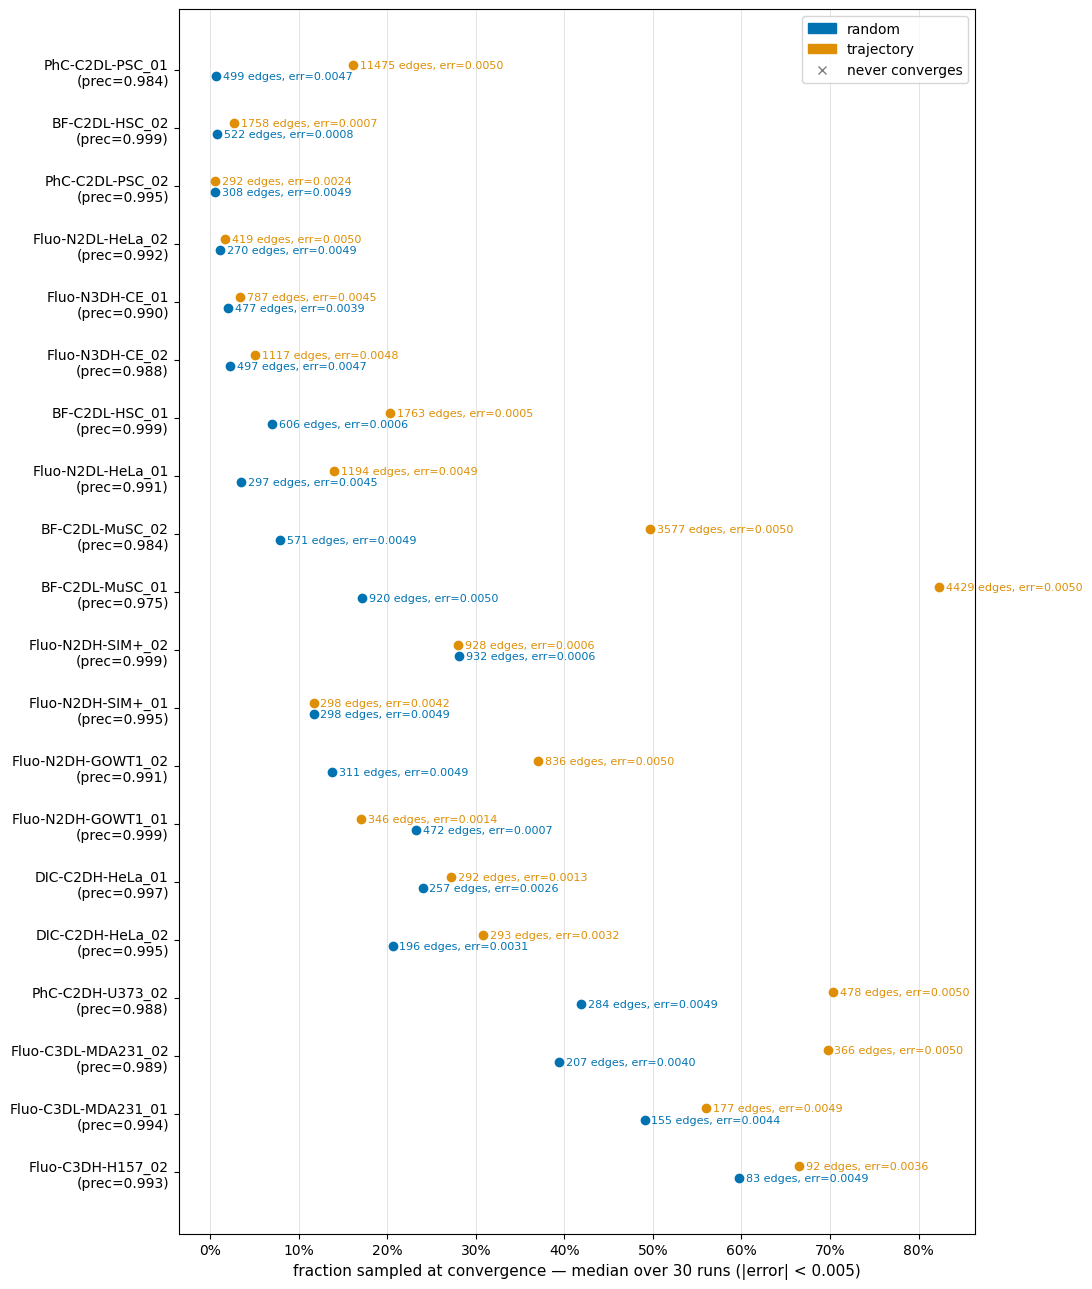

In [33]:
# ds_order = (
#     conv.groupby('ds_name')['conv_frac_median'].mean()
#     .sort_values()
#     .index.tolist()
# )
ds_order = col_order[::-1]

fig, ax = plt.subplots(figsize=(11, len(ds_order) * 0.6 + 1))

offsets = {'random': -0.1, 'trajectory': 0.1}
for method, color in colors.items():
    sub = conv[conv['method'] == method].set_index('ds_name').reindex(ds_order)
    for i, ds_name in enumerate(ds_order):
        row = sub.loc[ds_name]
        y = i + offsets[method]
        if pd.isna(row['conv_frac_median']):
            ax.scatter(1.0, y, color=color, zorder=3, marker='x', s=60, linewidths=1.5)
        else:
            ax.scatter(row['conv_frac_median'], y, color=color, zorder=3)
            ax.annotate(
                f"{row['conv_n_edges_median']} edges, err={row['error_at_conv_median']:.4f}",
                xy=(row['conv_frac_median'], y),
                xytext=(5, 0), textcoords='offset points',
                fontsize=8, va='center', color=color,
            )

true_prec_lookup = ds_info.set_index('ds_name')['true_precision']
yticklabels = [f"{ds}\n(prec={true_prec_lookup[ds]:.3f})" for ds in ds_order]
ax.set_yticks(range(len(ds_order)))
ax.set_yticklabels(yticklabels, fontsize=10)
ax.set_xlabel(f'fraction sampled at convergence — median over 30 runs (|error| < {THRESHOLD})', fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.tick_params(axis='x', labelsize=10)
legend_handles = [mpatches.Patch(color=c, label=m) for m, c in colors.items()]
legend_handles.append(plt.Line2D([0], [0], marker='x', color='grey', linestyle='none', label='never converges'))
ax.legend(handles=legend_handles, fontsize=10)
ax.grid(axis='x', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()